In [ ]:
import sys
import os

# Thiết lập đường dẫn để import từ thư mục src
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Bây giờ bạn có thể import bình thường
from src.models.semi_supervised import run_self_training
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

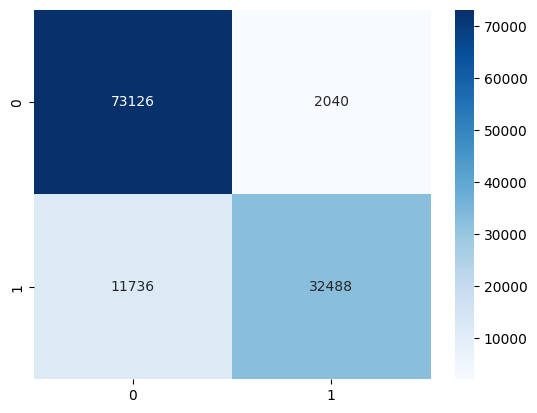

In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from src.models.semi_supervised import run_self_training
from sklearn.ensemble import RandomForestClassifier

# 1. Load lại dữ liệu
df = pd.read_csv("../data/processed/hotel_prepared.csv")
df_model = pd.get_dummies(df.drop(columns=['lead_time_cat'], errors='ignore'))
X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

# 2. Train lại mô hình (hoặc load model đã lưu)
# Nếu bạn chưa lưu model ra file, bạn cần chạy lại bước training ở đây
model_semi = run_self_training(RandomForestClassifier(), X, y, labeled_ratio=0.2)

# 3. Bây giờ bạn mới có thể chạy confusion matrix
cm = confusion_matrix(y, model_semi.predict(X))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [8]:
# Giả sử bạn đã chạy mô hình Supervised ở Notebook 04 và lưu kết quả
# Bạn có thể tạo bảng so sánh nhanh như sau:
from sklearn.metrics import f1_score, accuracy_score

# Dự đoán
y_pred_semi = model_semi.predict(X)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score'],
    'Semi-Supervised': [accuracy_score(y, y_pred_semi), f1_score(y, y_pred_semi)]
})

print("BẢNG TỔNG KẾT HIỆU NĂNG MÔ HÌNH:")
display(results)

BẢNG TỔNG KẾT HIỆU NĂNG MÔ HÌNH:


,Metric,Semi-Supervised
0,Accuracy,0.884613
1,F1-Score,0.825071
